### Polymarket

In [3]:
%run eda_starter_template.py


[Memory] Initial memory usage: 267.52 MB

Loading Bitcoin data from /Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/data/Coin Metrics/coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 267.52 MB
[Memory] After loading Bitcoin data: 271.20 MB (Δ 3.69 MB)
Error loading Bitcoin data: No such file or directory (os error 2): ...ne Project/lse-bitcoin-analytics-capstone-template/data/Coin Metrics/coinmetrics_btc.csv (set POLARS_VERBOSE=1 to see full path)

This error occurred with the following context stack:
	[1] 'csv scan'
	[2] 'with_columns'
	[3] 'sink'

Loading Polymarket data from /Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/data/Polymarket...
[Memory] Before loading Polymarket data: 271.22 MB
[Memory] After loading Polymarket data: 271.22 MB (Δ 0.00 MB)

[Memory] Final memory usage: 271.22 MB (Total Δ: 3.70 MB)

EDA Layout Complete. Check the 'plots' directory for visualizations.


In [4]:
# edit your directory
%run '/Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/data/download_data.py'

--- Downloading Capstone Data ---


Retrieving folder contents


Retrieving folder 1mgd1yrowPdQ0JKtdnKBQYHpvcdyRlXcV Coin Metrics
Processing file 1IUADRKckAZVoFYIJjTt9f_la-CQmnXIN coinmetrics_btc.csv
Processing file 1KVBZIl45-DnY0EzbA6-qFZi7kvu1iH8H coinmetrics_spec.md
Retrieving folder 1f_RjuR2AVTpuJeX6jgeoKcspjUp9_lif Polymarket
Processing file 14v0AUTMO6GwQ4ItLNRI8EuxLXplvCoGt finance_politics_event_stats.parquet
Processing file 1oF4B2zvi21br9a6NFVTwjAB8mfNuLdYx finance_politics_markets.parquet
Processing file 1z4nfPZL04Rkhp82piCvqRFerKBQbrXCh finance_politics_odds_history.parquet
Processing file 1QrWoxsFnfxv7Qs1lR4j2wpTs20MqOLnk finance_politics_summary.parquet
Processing file 1K1DjGkN4fkDMRXqZekS_-vRn-WErRLsz finance_politics_tokens.parquet
Processing file 1GO00RPaS7Q2ncX0fcUHiBLyy4bZR4_Yt finance_politics_trades.parquet
Processing file 1SwimJ6dcwl8TWUR1qKWsC1pzXAb9RHTs polymarket_btc_analytics_schema.md


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1IUADRKckAZVoFYIJjTt9f_la-CQmnXIN
To: /Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/eda/tmp_capstone_data/Coin Metrics/coinmetrics_btc.csv
100%|██████████| 2.42M/2.42M [00:00<00:00, 9.81MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KVBZIl45-DnY0EzbA6-qFZi7kvu1iH8H
To: /Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/eda/tmp_capstone_data/Coin Metrics/coinmetrics_spec.md
100%|██████████| 4.85k/4.85k [00:00<00:00, 1.34MB/s]
Downloading...
From: https://drive.google.com/uc?id=14v0AUTMO6GwQ4ItLNRI8EuxLXplvCoGt
To: /Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/eda/tmp_capstone_data/Polymarket/finance_politics_event_stats.parquet
100%|██████████| 1.43M/1.43M [00:00<00:00, 8.75MB/s]
Downloading...
From: https://drive.googl

Organizing files...
  Keeping: Coin Metrics/coinmetrics_btc.csv
  Keeping: Coin Metrics/coinmetrics_spec.md
  Keeping: Polymarket/finance_politics_odds_history.parquet
  Keeping: Polymarket/finance_politics_summary.parquet
  Keeping: Polymarket/finance_politics_trades.parquet
  Keeping: Polymarket/finance_politics_markets.parquet
  Keeping: Polymarket/polymarket_btc_analytics_schema.md
  Keeping: Polymarket/finance_politics_tokens.parquet
  Keeping: Polymarket/finance_politics_event_stats.parquet

Successfully organized 9 file(s).
--- Finished downloading ---

Data download and organization complete.



Download completed


In [5]:
import os
import pandas as pd

COINMETRICS_PATH = '/Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/eda/data/Coin Metrics/coinmetrics_btc.csv'
POLYMARKET_DIR = '/Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/eda/data/Polymarket'

# Load Bitcoin data
btc_df = load_bitcoin_data(COINMETRICS_PATH)

# Debug: Check directory and files
print("\n" + "="*80)
print("POLYMARKET DATA LOADING")
print("="*80)
print(f"\nDirectory: {POLYMARKET_DIR}")
print(f"Directory exists: {os.path.exists(POLYMARKET_DIR)}")

if os.path.exists(POLYMARKET_DIR):
    print("\nFiles in directory:")
    all_files = os.listdir(POLYMARKET_DIR)
    for file in sorted(all_files):
        filepath = os.path.join(POLYMARKET_DIR, file)
        size = os.path.getsize(filepath) / (1024*1024)  # Size in MB
        print(f"  {file:50s} ({size:.2f} MB)")
else:
    print("\n✗ ERROR: Directory does not exist!")

print("\n" + "-"*80)

# Load Polymarket data with DETAILED error messages
poly_data = {}

files_to_load = [
    ('markets', 'finance_politics_markets.parquet'),
    ('odds_history', 'finance_politics_odds_history.parquet'),
    ('summary', 'finance_politics_summary.parquet'),
    ('tokens', 'finance_politics_tokens.parquet'), 
    ('trades', 'finance_politics_trades.parquet'),
    ('event_stats', 'finance_politics_event_stats.parquet')
]

for name, filename in files_to_load:
    filepath = os.path.join(POLYMARKET_DIR, filename)
    
    print(f"\n{name}:")
    print(f"  Looking for: {filename}")
    print(f"  Full path: {filepath}")
    print(f"  File exists: {os.path.exists(filepath)}")
    
    if not os.path.exists(filepath):
        print(f"  ✗ SKIPPED: File not found")
        continue
    
    try:
        poly_data[name] = pd.read_parquet(filepath)
        print(f"  ✓ SUCCESS: Loaded {len(poly_data[name]):,} rows, {len(poly_data[name].columns)} columns")
        print(f"  Columns: {', '.join(poly_data[name].columns[:5].tolist())}{'...' if len(poly_data[name].columns) > 5 else ''}")
        
    except Exception as e:
        print(f"  ✗ ERROR: {type(e).__name__}")
        print(f"  Message: {str(e)}")

# Final summary
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Bitcoin data: ✓ {len(btc_df):,} rows")
print(f"Polymarket datasets loaded: {len(poly_data)}/{len(files_to_load)}")

if len(poly_data) > 0:
    for name, df in poly_data.items():
        print(f"  ✓ {name:15s}: {len(df):,} rows")
else:
    print("\n⚠ WARNING: No Polymarket files loaded!")
    print("\nPossible reasons:")
    print("  1. Files have different names than expected")
    print("  2. Files are in a different directory")
    print("  3. Files haven't been downloaded yet")
    print("  4. pyarrow library not installed (run: pip install pyarrow)")

print("="*80)


Loading Bitcoin data from /Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/eda/data/Coin Metrics/coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 301.67 MB
[Memory] After loading Bitcoin data: 317.97 MB (Δ 16.30 MB)
Successfully loaded 6221 rows.

POLYMARKET DATA LOADING

Directory: /Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/eda/data/Polymarket
Directory exists: True

Files in directory:
  finance_politics_event_stats.parquet               (1.37 MB)
  finance_politics_markets.parquet                   (3.22 MB)
  finance_politics_odds_history.parquet              (16.96 MB)
  finance_politics_summary.parquet                   (4.31 MB)
  finance_politics_tokens.parquet                    (9.87 MB)
  finance_politics_trades.parquet                    (3156.20 MB)
  polymarket_btc_analytics_schema.md                 (0.00 MB)

-------------------------------------------------------------------------------

In [6]:
poly_data

{'markets':       market_id                                           question  \
 0        242851  Will Bongbong Marcos be elected President of t...   
 1        242873  Will Sarah Palin win Alaska's special election...   
 2        242918  Will US student loan payments resume by Electi...   
 3        243183       Will $ETH be above $3,000 on April 20, 2022?   
 4        243192  Will Brian Kemp win the Republican nomination ...   
 ...         ...                                                ...   
 78316    242646  Will the total value locked (TVL) in DeFi be $...   
 78317    242686  2022 Hungarian elections: Will Fidesz win at l...   
 78318    242687  Will the price of wheat close above $1050 on A...   
 78319    242688  Will the Progressive Conservative Party win a ...   
 78320    242690  Will Joe Biden's FiveThirtyEight approval rati...   
 
                                                     slug  \
 0      will-bongbong-marcos-be-elected-president-of-t...   
 1      will-

In [8]:
btc_df

time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,FlowInExUSD,FlowOutExNtv,FlowOutExUSD,HashRate,IssTotNtv,IssTotUSD,PriceBTC,PriceUSD,ROI1yr,ROI30d,ReferenceRate,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
datetime[μs],i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64
2009-01-03 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-04 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-05 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-06 00:00:00,0,0,1614334884,1614334884,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-07 00:00:00,0,0,1614334885,1614334885,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-01-10 00:00:00,608784,55908713,1768101454,1768101454,162,1.610013,1.8058e12,1.8058e12,2.0853467,25172.379573,2.2757e9,25704.121161,2.3238e9,1.1796e9,506.25,4.5768e7,1,90406.142411,-4.593729,-2.394179,90539.603229,29.348301,77853.756824,90539.603229,1.9974e7,2.4808e6,2.2428e11,2.0826e7,492984,1049925,2.9985e9
2026-01-11 00:00:00,536405,55924280,1768186822,1768186822,122,1.615856,1.8120e12,1.8120e12,1.915416,27810.205536,2.5229e9,24486.469835,2.2213e9,8.8831e8,381.25,3.4586e7,1,90717.206315,-4.11103,0.426869,90406.142411,29.333069,77790.505193,90406.142411,1.9974e7,2.4846e6,2.2539e11,2.0826e7,289219,572262,4.3998e9
2026-01-12 00:00:00,638422,55917951,1768275291,1768275291,142,1.623512,1.8205e12,1.8205e12,2.3225772,26842.012928,2.4464e9,29771.239469,2.7134e9,1.0339e9,443.75,4.0444e7,1,91141.149849,-3.404872,0.99272,90717.206315,29.145653,78047.851052,90717.206315,1.9975e7,2.4821e6,2.2622e11,2.0826e7,405384,845895,1.3448e10


In [7]:
category = poly_data['markets'].groupby('category')
print(category.groups.keys())
category.size()

dict_keys(['', 'Business', 'Coronavirus', 'Coronavirus-', 'Crypto', 'Global Politics', 'Politics', 'Pop-Culture ', 'Tech', 'US-current-affairs', 'Ukraine & Russia'])


category
                      77516
Business                113
Coronavirus               3
Coronavirus-              1
Crypto                  340
Global Politics          56
Politics                  1
Pop-Culture               4
Tech                      2
US-current-affairs      265
Ukraine & Russia         20
dtype: int64

In [9]:
# 1. Define your keyword map
keyword_map = {
    'Crypto': 'bitcoin|eth|solana|crypto|token|airdrop',
    'Politics': 'trump|biden|harris|election|senate|republican|democrat',
    'Ukraine & Russia': 'ukraine|russia|putin|zelensky|kremlin',
    'Pop-Culture': 'oscars|grammy|taylor swift|box office|celebrity',
    'Tech': 'ai|openai|gpt|google|nvidia|meta|apple',
    'Global Politics': 'israel|gaza|iran|china|taiwan|uk|london'
}

# 2. Filter for only the rows where category is blank
blank_mask = (poly_data['markets']['category'] == '') | (poly_data['markets']['category'].isna())

# 3. Loop through the map and update blank categories based on question text
for cat, keywords in keyword_map.items():
    # Only update if the row is currently blank AND the question contains a keyword
    match_mask = blank_mask & poly_data['markets']['question'].str.contains(keywords, case=False, na=False)
    poly_data['markets'].loc[match_mask, 'category'] = cat

# 4. See how many are left blank now
print(poly_data['markets']['category'].value_counts())

category
Crypto                57852
Politics              10909
                       7421
Tech                    766
Global Politics         694
Ukraine & Russia        293
US-current-affairs      265
Business                113
Pop-Culture               4
Coronavirus               3
Coronavirus-              1
Name: count, dtype: int64


### Calculate SPD

In [13]:
btc_pandas_df = btc_df.to_pandas()
btc_pandas_df["spd"] = (1/btc_pandas_df["PriceUSD"])*100_000_000


### Top 10 Volume 

In [56]:
poly_data_markets = poly_data["markets"]
print(poly_data_markets["created_at"].max())
print(poly_data_markets["created_at"].min())
top_1000_volume = poly_data_markets.nlargest(1000, "volume")

2025-12-10 05:32:21
2020-10-02 16:10:01


In [207]:
top_1000_volume

,market_id,question,slug,event_slug,category,volume,active,closed,created_at,end_date
2490,253591,Will Donald Trump win the 2024 US Presidential...,will-donald-trump-win-the-2024-us-presidential...,presidential-election-winner-2024,Politics,1.531479e+09,True,True,2024-01-04 17:33:51,2024-11-05 12:00:00
2496,253597,Will Kamala Harris win the 2024 US Presidentia...,will-kamala-harris-win-the-2024-us-presidentia...,presidential-election-winner-2024,Politics,1.037039e+09,True,True,2024-01-04 17:40:17,2024-11-04 12:00:00
4619,511754,Will Donald Trump be inaugurated?,will-donald-trump-be-inaugurated,who-will-be-inaugurated-as-president,Politics,4.004095e+08,True,True,2024-11-01 20:59:58,2025-01-20 12:00:00
4909,512340,Will Nicolae Ciucă win the 2024 Romanian Presi...,will-nicolae-ciuca-win-the-2024-romanian-presi...,romania-presidential-election,Politics,3.265077e+08,True,True,2024-11-07 23:53:29,2024-12-08 12:00:00
2127,253642,Will any other Republican Politician win the 2...,will-any-other-republican-politician-win-the-2...,presidential-election-winner-2024,Politics,2.416551e+08,True,True,2024-01-06 19:52:35,2024-11-05 00:00:00
...,...,...,...,...,...,...,...,...,...,...
7230,526659,"Will Bitcoin reach $105,000 again by March 31?",will-bitcoin-reach-105000-again-by-march-31,what-price-will-bitcoin-hit-by-march-31,Tech,1.875629e+06,True,True,2025-03-03 19:55:21,2025-03-31 12:00:00
15559,565927,"Bitcoin above $118,000 on July 28?",bitcoin-above-118000-on-july-28,bitcoin-above-118000-on-july-28,Crypto,1.872255e+06,True,True,2025-07-21 12:35:45,2025-07-28 16:00:00
56428,659268,"Will Ethereum dip to $3,000 in November?",will-ethereum-dip-to-3000-in-november-2025,what-price-will-ethereum-hit-in-november-2025,Crypto,1.870700e+06,True,True,2025-11-01 01:10:20,2025-12-01 05:00:00
13900,559655,Will Josh Shapiro win the 2028 Democratic pres...,will-josh-shapiro-win-the-2028-democratic-pres...,democratic-presidential-nominee-2028,Politics,1.870236e+06,True,False,2025-07-03 20:37:01,2028-11-07 00:00:00


In [58]:
poly_data_odds = poly_data["odds_history"]
poly_data_odds

,market_id,token_id,timestamp,price
0,255140,4743579536152330606866939019100172195245171947...,1970-01-20 21:10:04.802,0.0550
1,255140,4743579536152330606866939019100172195245171947...,1970-01-20 21:11:31.203,0.0550
2,255140,4743579536152330606866939019100172195245171947...,1970-01-20 21:12:57.604,0.0550
3,255140,4743579536152330606866939019100172195245171947...,1970-01-20 21:14:24.002,0.0550
4,255140,4743579536152330606866939019100172195245171947...,1970-01-20 21:15:50.403,0.0550
...,...,...,...,...
2143176,897329,1441341842174471672181235644969822857103541674...,1970-01-21 10:55:12.022,0.9595
2143177,897329,1441341842174471672181235644969822857103541674...,1970-01-21 10:56:38.419,0.9595
2143178,897329,1441341842174471672181235644969822857103541674...,1970-01-21 10:58:04.822,0.9640
2143179,897329,1441341842174471672181235644969822857103541674...,1970-01-21 10:59:31.225,0.9640


In [59]:
poly_data_trades = poly_data["trades"]
poly_data_trades

,trade_id,market_id,token_id,timestamp,price,size,side,maker_address,taker_address
0,0x036e539d9361b15d9ebee9bbd1aebf42e45a1e07a9bd...,570360,2148977251641003858655674434239298204418999936...,1970-01-21 09:52:39.845,0.977000,281.054246,BUY,0x27d76669db4321111b08fcc7e1a5bf622b98693c,0xc5d563a36ae78145c45a50134d48a1215220f80a
1,0x8685bb4a3134f9f664ed7e619b8ea693352f94285b34...,570360,2148977251641003858655674434239298204418999936...,1970-01-21 09:52:39.857,0.977000,28.000000,BUY,0x33dcee9b336230ed7460c98bec8ff3115296a539,0xc5d563a36ae78145c45a50134d48a1215220f80a
2,0xab71cfe8f3cb18e629b873b65b84ea386924891e758e...,570360,2148977251641003858655674434239298204418999936...,1970-01-21 09:52:39.871,0.977000,182.000000,BUY,0x87370aa54b8f70fa1c9637f367aadd3156782bff,0xc5d563a36ae78145c45a50134d48a1215220f80a
3,0xfe619b29a0b6aa958cbd565c18f0aedc451139aac0f9...,570360,2148977251641003858655674434239298204418999936...,1970-01-21 09:52:39.889,0.977081,49.000000,BUY,0xa3ad70cf48a2f2b44163e798223c01a2c2536866,0xc5d563a36ae78145c45a50134d48a1215220f80a
4,0x953032bcaecd5bf0007c44acddb0c6c9c80f2c063a55...,570360,2148977251641003858655674434239298204418999936...,1970-01-21 09:52:39.925,0.978000,147.800000,BUY,0x4ee06f42e20ee128db78d42252176bf3a9ce7cce,0xc5d563a36ae78145c45a50134d48a1215220f80a
...,...,...,...,...,...,...,...,...,...
27013719,0x4a86d7efa03d352f6990dfb61bd87f3c31a84c9b57f1...,561985,2652814724933719576712958625055698322914303600...,1970-01-21 10:59:54.319,0.992000,5.413250,BUY,,
27013720,0x6939770889fa51da300bbab08bf1750853103848a59d...,562004,3337233094702386052587063075854913790217057691...,1970-01-21 10:59:54.319,0.990000,23.151500,BUY,,
27013721,0x126f0595e5e8bc7039206ffc20ced52f9db85fa5ec9c...,561973,2782897664868246677877699907621542377776697298...,1970-01-21 10:59:54.319,0.961000,25.005179,BUY,,
27013722,0x4b070936d6916aa985ad7b1dc9d6e5899642172b4003...,561991,8409529381329385248635760260604838650759146033...,1970-01-21 10:59:54.319,0.995000,25.005000,BUY,,


In [83]:
poly_data_trades["date"] = pd.to_datetime(poly_data_trades["timestamp"].astype("int64"), unit="ms").dt.normalize()
print(poly_data_trades["date"].head())

0   2025-11-19
1   2025-11-19
2   2025-11-19
3   2025-11-19
4   2025-11-19
Name: date, dtype: datetime64[ns]


In [84]:

trades_with_questions = poly_data_trades.merge(
    poly_data_markets,
    on="market_id",
    how="inner"
)

In [88]:
daily_odds = (
    trades_with_questions
    .groupby(["market_id", "question", "date"])["price"]
    .mean()
    .reset_index()
    .sort_values(["market_id", "date"])
)

In [89]:
daily_odds

,market_id,question,date,price
0,510319,Trump ends Ukraine war in first 90 days?,2025-04-07,0.032923
1,510319,Trump ends Ukraine war in first 90 days?,2025-04-08,0.027126
2,510319,Trump ends Ukraine war in first 90 days?,2025-04-09,0.025042
3,510319,Trump ends Ukraine war in first 90 days?,2025-04-10,0.022826
4,510319,Trump ends Ukraine war in first 90 days?,2025-04-11,0.023415
...,...,...,...,...
143974,904395,Will Stacy Rogers win the 2026 Kansas Governor...,2025-12-10,0.500000
143975,904740,"Bitcoin Up or Down - December 11, 7PM ET",2025-12-10,0.510000
143976,904899,"Bitcoin Up or Down - December 10, 7:45PM-8:00P...",2025-12-10,0.495496
143977,904934,"Bitcoin Up or Down - December 10, 8:15PM-8:30P...",2025-12-10,0.495000


In [91]:
print(daily_odds["question"].nunique())
print(daily_odds.shape)

36043
(143979, 4)


## Analysis 1
### Step 1 : ACF plot
An Autocorrelation Function (ACF) plot displays the correlation of a time series with its own lagged values.

When odds move, it means people are reacting to real news and putting real money on it.
The ACF just tells you: "how many days does this reaction last in the betting market?"

### Core Idea

News Event 

   ↓

Polymarket odds move (people bet based on news)

   ↓

ACF tells you how long odds keep moving (signal persistence)

   ↓
   
Within that window → does Bitcoin price also move?

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import acf
from scipy import stats

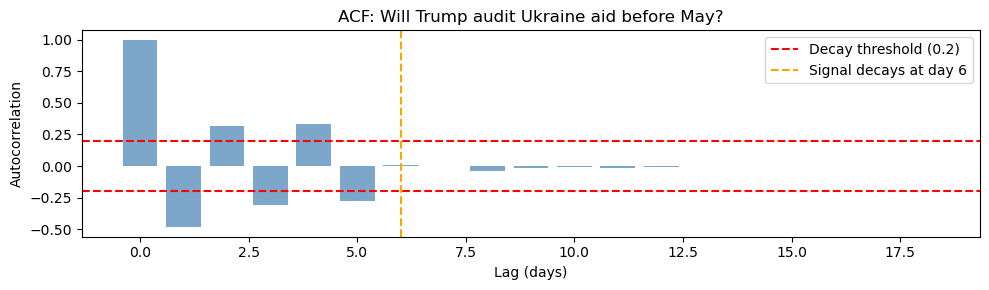

→ Signal persists for ~6 days: Will Trump audit Ukraine aid before May?


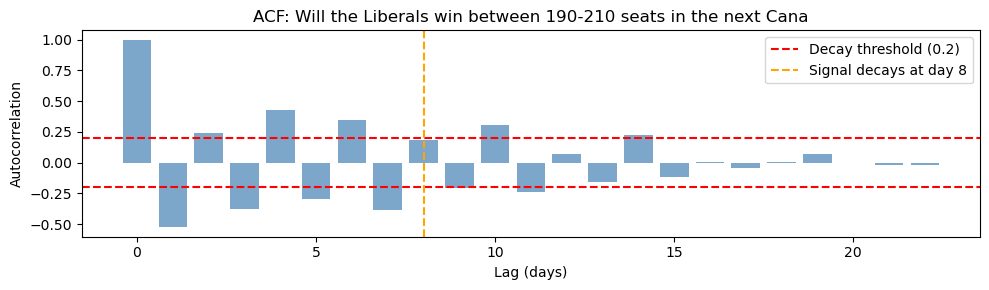

→ Signal persists for ~8 days: Will the Liberals win between 190-210 seats in the next Cana


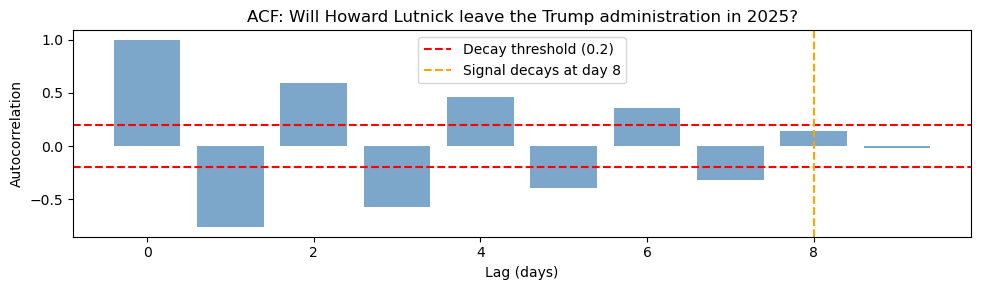

→ Signal persists for ~8 days: Will Howard Lutnick leave the Trump administration in 2025?


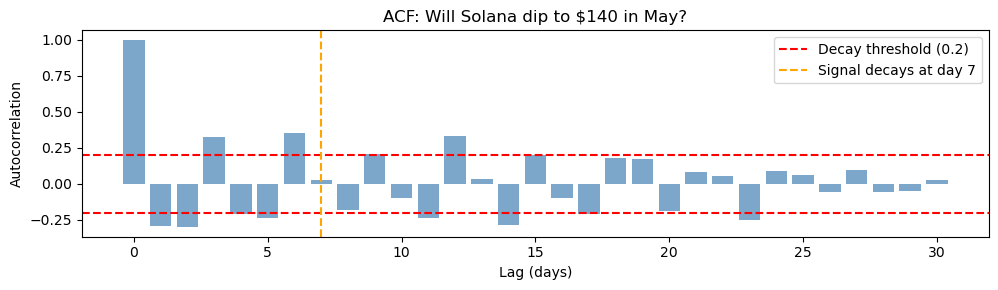

→ Signal persists for ~7 days: Will Solana dip to $140 in May?


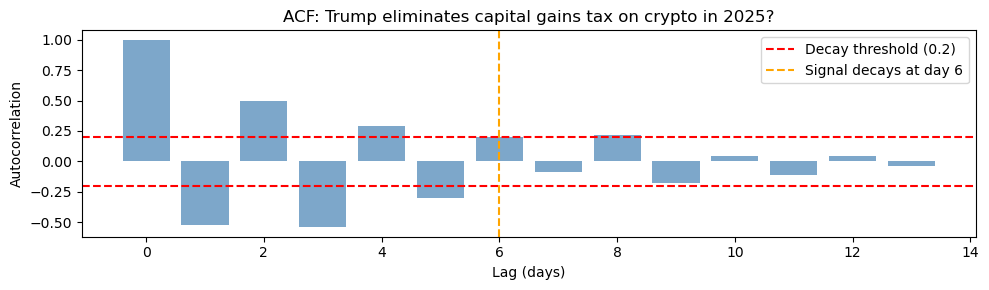

→ Signal persists for ~6 days: Trump eliminates capital gains tax on crypto in 2025?


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


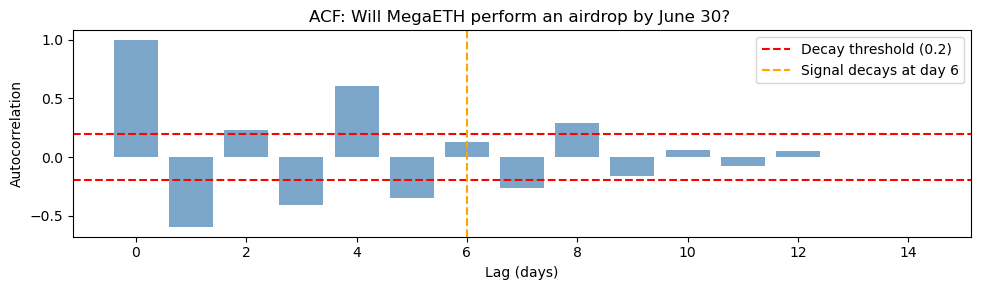

→ Signal persists for ~6 days: Will MegaETH perform an airdrop by June 30? 


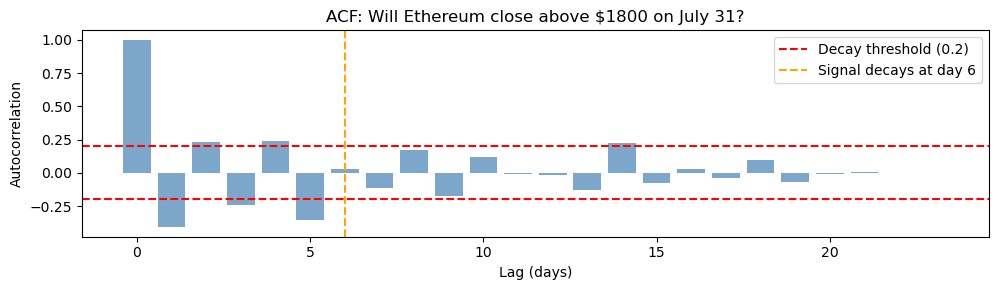

→ Signal persists for ~6 days: Will Ethereum close above $1800 on July 31?


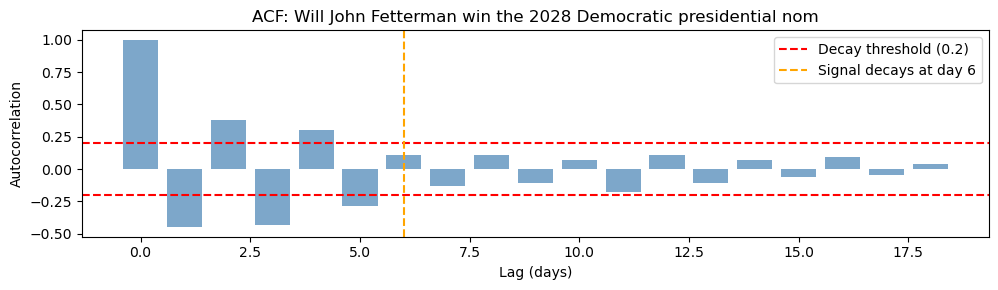

→ Signal persists for ~6 days: Will John Fetterman win the 2028 Democratic presidential nom


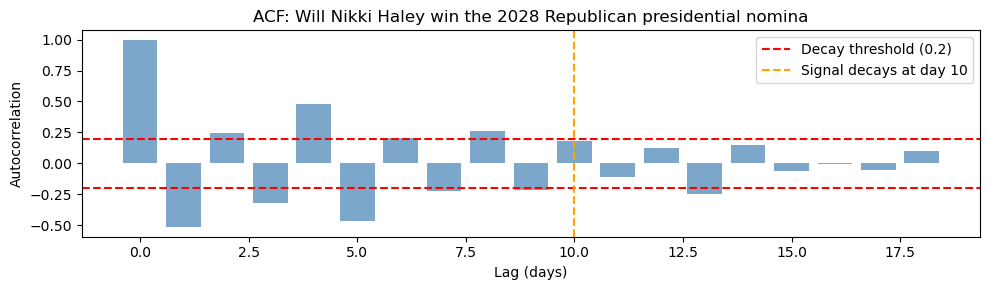

→ Signal persists for ~10 days: Will Nikki Haley win the 2028 Republican presidential nomina


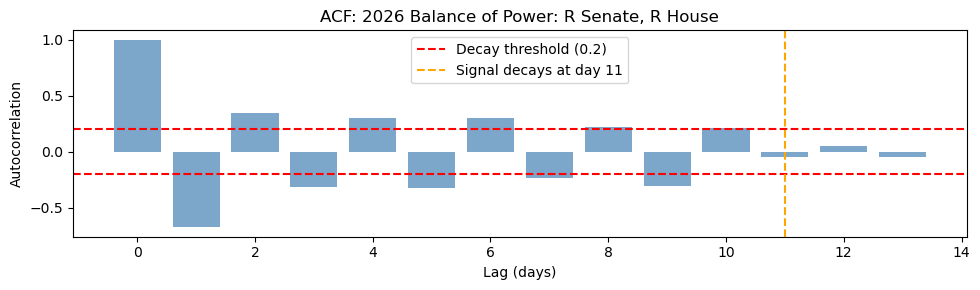

→ Signal persists for ~11 days: 2026 Balance of Power: R Senate, R House


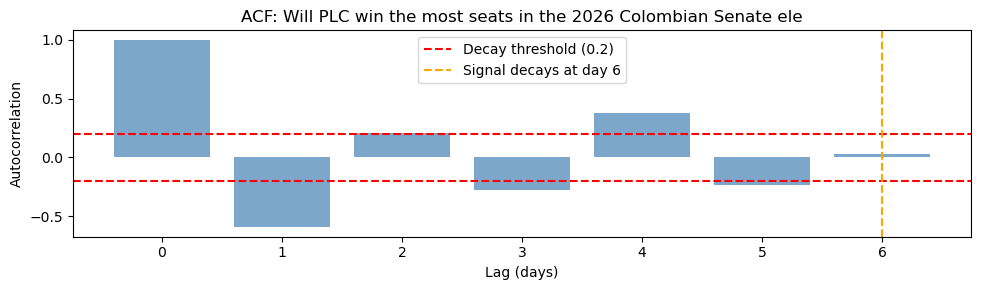

→ Signal persists for ~6 days: Will PLC win the most seats in the 2026 Colombian Senate ele


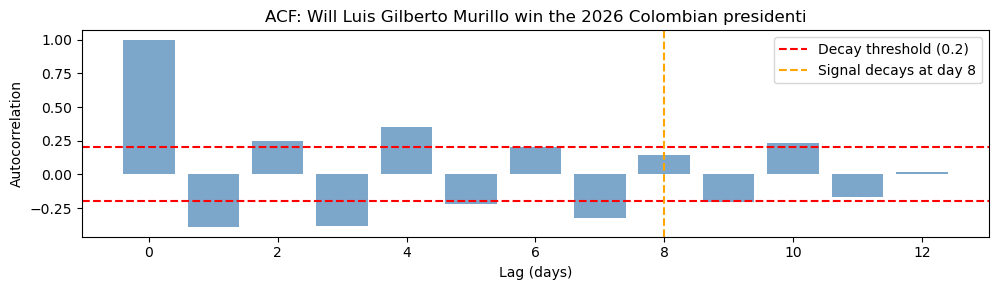

→ Signal persists for ~8 days: Will Luis Gilberto Murillo win the 2026 Colombian presidenti


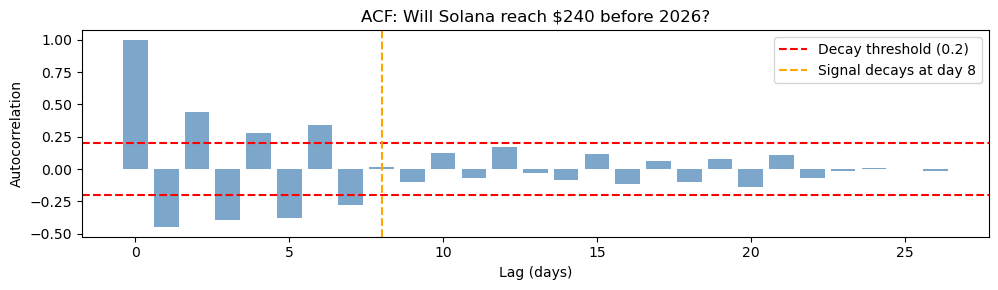

→ Signal persists for ~8 days: Will Solana reach $240 before 2026?


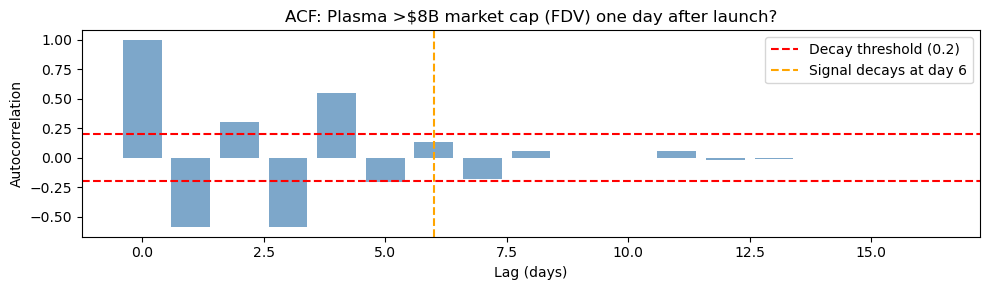

→ Signal persists for ~6 days: Plasma >$8B market cap (FDV) one day after launch?


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


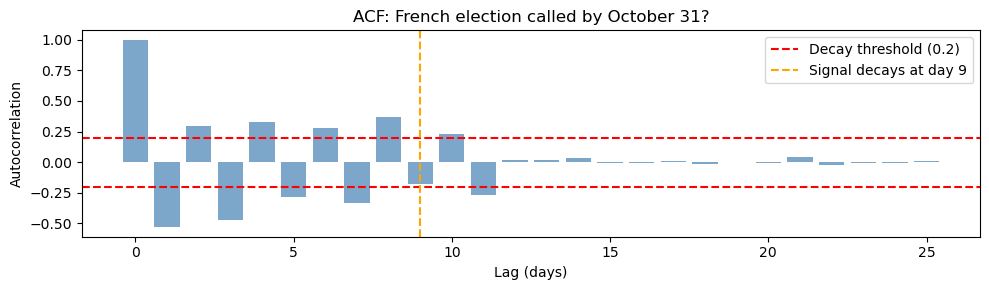

→ Signal persists for ~9 days: French election called by October 31?


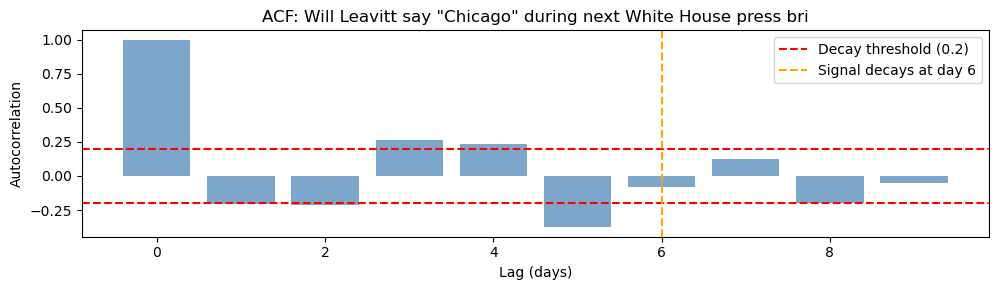

→ Signal persists for ~6 days: Will Leavitt say "Chicago" during next White House press bri


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


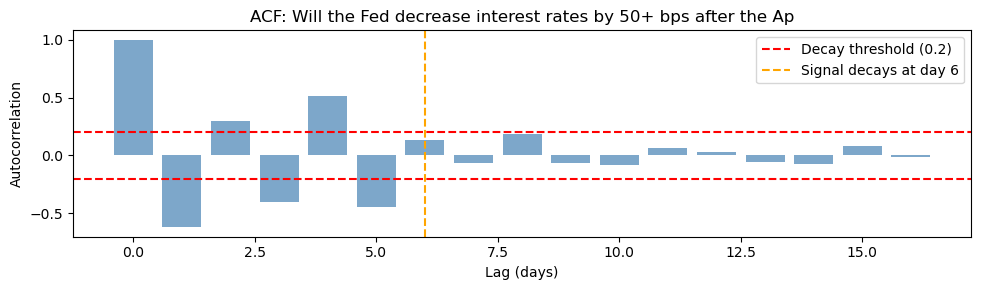

→ Signal persists for ~6 days: Will the Fed decrease interest rates by 50+ bps after the Ap


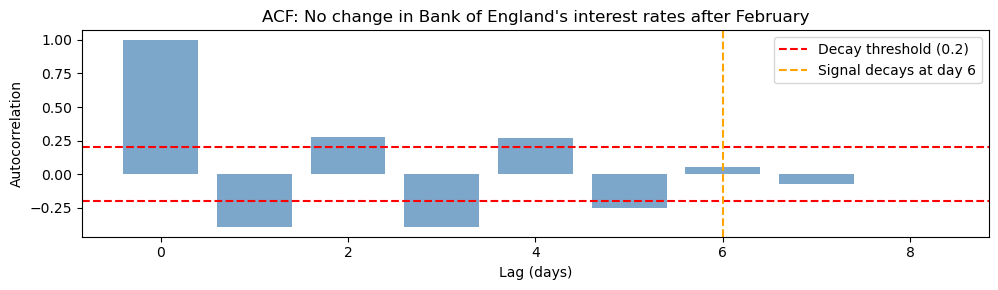

→ Signal persists for ~6 days: No change in Bank of England's interest rates after February


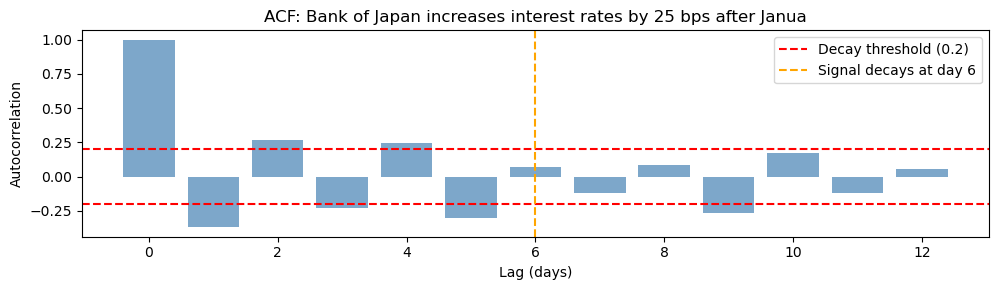

→ Signal persists for ~6 days: Bank of Japan increases interest rates by 25 bps after Janua


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


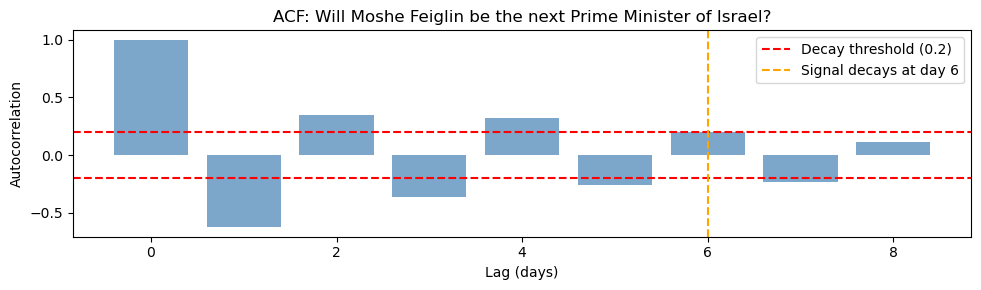

→ Signal persists for ~6 days: Will Moshe Feiglin be the next Prime Minister of Israel?


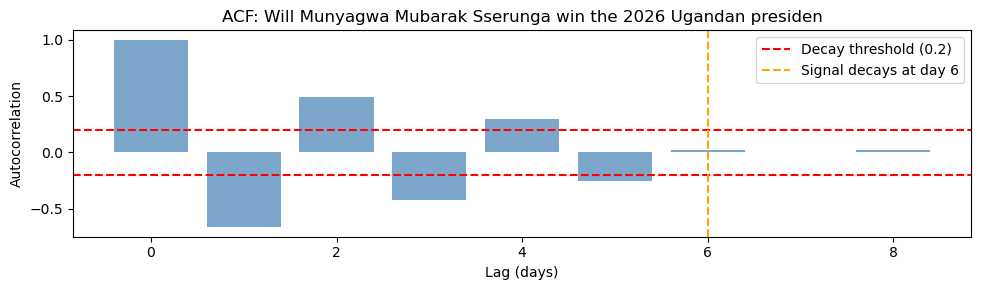

→ Signal persists for ~6 days: Will Munyagwa Mubarak Sserunga win the 2026 Ugandan presiden


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


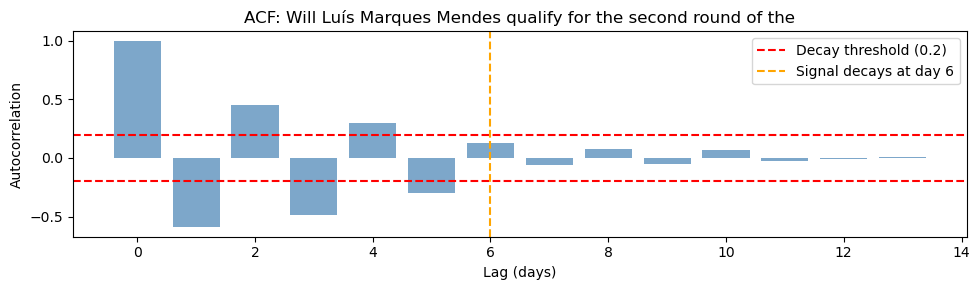

→ Signal persists for ~6 days: Will Luís Marques Mendes qualify for the second round of the


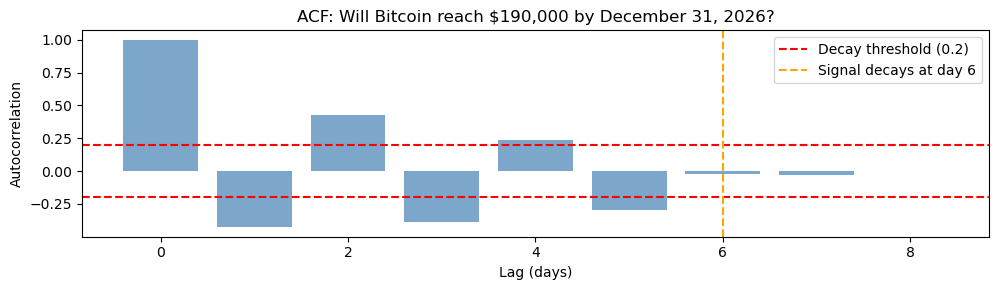

→ Signal persists for ~6 days: Will Bitcoin reach $190,000 by December 31, 2026?


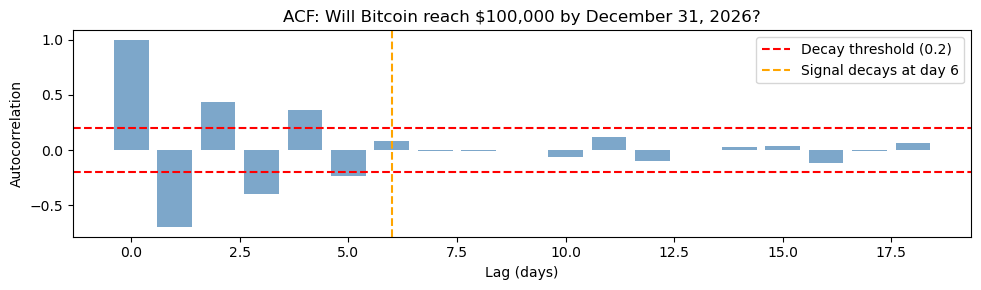

→ Signal persists for ~6 days: Will Bitcoin reach $100,000 by December 31, 2026?


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


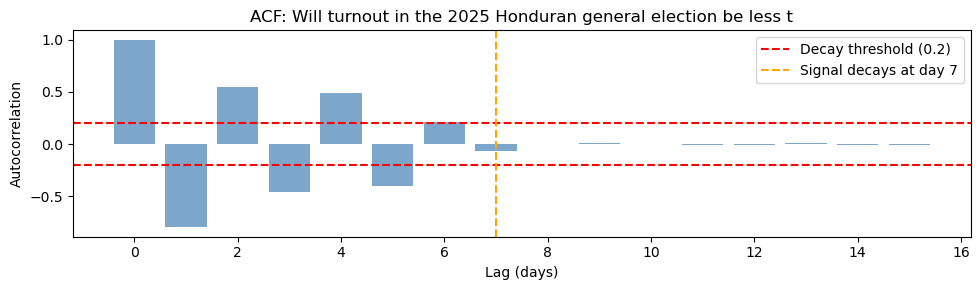

→ Signal persists for ~7 days: Will turnout in the 2025 Honduran general election be less t


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


In [170]:
FOCUS_MARKETS = daily_odds["question"].unique()

def plot_acf_for_market(market_name, poly_df, max_lag=30):
    df = poly_df[poly_df["question"] == market_name].copy()
    df_start = df["date"].min()
    df_end = df["date"].max()
    duration = df_end - df_start
    if duration.days < 14:
        # print(f"Not enough data for: {market_name}")
        return None

    # Use daily change in odds (not raw odds)
    df["odds_change"] = df["price"].diff()
    series = df["odds_change"].dropna()

    if df["price"].std() < 0.05:
        # print(f"Skipping - odds too stable: {market_name[:60]}")
        return None

    acf_vals = acf(series, nlags=max_lag, fft=True)
    decay_day = next((i for i, v in enumerate(acf_vals[1:], start=1) if abs(v) < 0.2), max_lag)

    if decay_day == max_lag:
        return None

    if decay_day > 5:
        fig, ax = plt.subplots(figsize=(10, 3))
        ax.bar(range(len(acf_vals)), acf_vals, color="steelblue", alpha=0.7)
        ax.axhline(0.2, color="red", linestyle="--", label="Decay threshold (0.2)")
        ax.axhline(-0.2, color="red", linestyle="--")
        ax.axvline(decay_day, color="orange", linestyle="--", label=f"Signal decays at day {decay_day}")
        ax.set_title(f"ACF: {market_name[:60]}")
        ax.set_xlabel("Lag (days)")
        ax.set_ylabel("Autocorrelation")
        ax.legend()
        plt.tight_layout()
        os.makedirs("acf_plots", exist_ok=True)
        plt.savefig(f"acf_plots/acf_{market_name[:30].replace(' ','_')}.png", dpi=150)
        plt.show()

        print(f"→ Signal persists for ~{decay_day} days: {market_name[:60]}")
    
    return decay_day

signal_persistence = {}
for m in FOCUS_MARKETS:
    days = plot_acf_for_market(m, daily_odds)
    if days:
        signal_persistence[m] = days


In [171]:
signal_df = pd.DataFrame(
    signal_persistence.items(), 
    columns=["question", "signal_days"]
).sort_values("signal_days", ascending=False)

print(f"\nTotal markets with meaningful signal: {len(signal_df)}")
print(signal_df.to_string(index=False))


Total markets with meaningful signal: 2129
                                                                                                                                              question  signal_days
                                                                                                              2026 Balance of Power: R Senate, R House           11
                                                                                     Will Nikki Haley win the 2028 Republican presidential nomination?           10
                                                                                                                 French election called by October 31?            9
                                                                            Will the Liberals win between 190-210 seats in the next Canadian Election?            8
                                                                                           Will Howard Lutnick leave the Trump administr

In [172]:
signal_df = signal_df[
    (signal_df["signal_days"] >= 5)]
signal_df
print(signal_df.to_string(index=False))

                                                                                         question  signal_days
                                                         2026 Balance of Power: R Senate, R House           11
                                Will Nikki Haley win the 2028 Republican presidential nomination?           10
                                                            French election called by October 31?            9
                       Will the Liberals win between 190-210 seats in the next Canadian Election?            8
                                      Will Howard Lutnick leave the Trump administration in 2025?            8
                         Will Luis Gilberto Murillo win the 2026 Colombian presidential election?            8
                                                              Will Solana reach $240 before 2026?            8
                                                                  Will Solana dip to $140 in May?            7
 

### Step 2 : Time series and correlation
Big odds move on date X

    ↓

Wait lag_days (from ACF)

    ↓

Did Bitcoin go up or down?

    ↓

If consistently up → this market is a story candidate

In [173]:
FOCUS_MARKETS = signal_df[["question", "signal_days"]]
FOCUS_MARKETS

,question,signal_days
787,"2026 Balance of Power: R Senate, R House",11
749,Will Nikki Haley win the 2028 Republican presi...,10
1345,French election called by October 31?,9
235,Will the Liberals win between 190-210 seats in...,8
274,Will Howard Lutnick leave the Trump administra...,8
...,...,...
2105,MicroStrategy sells any Bitcoin by December 31...,5
39,"Will Bitcoin reach $250,000 by December 31, 2025?",5
340,Will the NDP win between 5 and 6 seats in the ...,5
1103,Will Trump agree to a tariff agreement with Br...,5


In [174]:
def find_events(question, daily_odds_df, threshold=0.05):
    df = daily_odds_df[daily_odds_df["question"] == question].copy()
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = df.set_index("date")[["price"]].resample("1D").mean().ffill()
    df["odds_change"] = df["price"].diff()

    events = df[df["odds_change"].abs() > threshold].copy()
    events["direction"] = events["odds_change"].apply(
        lambda x: "POSITIVE" if x > 0 else "NEGATIVE"
    )
    return events.reset_index()[["date", "price", "odds_change", "direction"]]

In [175]:

def event_study(question, lag_days, daily_odds_df, btc_df, threshold=0.05):
    events = find_events(question, daily_odds_df, threshold)
    if events.empty:
        return None

    results = []
    for _, ev in events.iterrows():
        future_date = ev["date"] + pd.Timedelta(days=lag_days)
        if ev["date"] in btc_df.index and future_date in btc_df.index:
            btc_return = (
                btc_df.loc[future_date, "PriceUSD"] - btc_df.loc[ev["date"], "PriceUSD"]
            ) / btc_df.loc[ev["date"], "PriceUSD"]

            results.append({
                "question":    question,
                "event_date":  ev["date"],
                "direction":   ev["direction"],
                "odds_change": ev["odds_change"],
                "lag_days":    lag_days,
                "btc_return":  round(btc_return, 4)
            })

    return pd.DataFrame(results)


In [176]:
btc_df = pd.read_csv("/Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/eda/data/Coin Metrics/coinmetrics_btc.csv")

In [177]:
daily_odds["price"] = pd.to_numeric(daily_odds["price"], errors="coerce")
print(daily_odds.dtypes)

market_id            object
question             object
date         datetime64[ns]
price               float64
dtype: object


In [178]:
btc_df = btc_df.set_index("time")
btc_df.index = pd.to_datetime(btc_df.index)


In [179]:
all_results = []
for _, row in FOCUS_MARKETS.iterrows():
    question = row["question"]
    lag = row["signal_days"]
    print(f"Processing: {question[:50]}...")
    res = event_study(question, lag, daily_odds, btc_df)
    if res is not None and not res.empty:
        all_results.append(res)
        print(f"  → {len(res)} events found")
    else:
        print(f"  → No events found")

print(f"\nTotal markets with results: {len(all_results)}")

Processing: 2026 Balance of Power: R Senate, R House...
  → 12 events found
Processing: Will Nikki Haley win the 2028 Republican president...
  → 13 events found
Processing: French election called by October 31?...
  → 14 events found
Processing: Will the Liberals win between 190-210 seats in the...
  → 13 events found
Processing: Will Howard Lutnick leave the Trump administration...
  → 9 events found
Processing: Will Luis Gilberto Murillo win the 2026 Colombian ...
  → 11 events found
Processing: Will Solana reach $240 before 2026?...
  → 15 events found
Processing: Will Solana dip to $140 in May?...
  → 18 events found
Processing: Will turnout in the 2025 Honduran general election...
  → 9 events found
Processing: Will Leavitt say "Chicago" during next White House...
  → 8 events found
Processing: Will John Fetterman win the 2028 Democratic presid...
  → 10 events found
Processing: Will MegaETH perform an airdrop by June 30? ...
  → 12 events found
Processing: Will Luís Marques Mend

In [205]:

results_df = pd.concat(all_results, ignore_index=True)
results_df
os.makedirs("output", exist_ok=True)
results_df.to_csv("output/results_dates.csv", index=False)


In [199]:

summary = (
    results_df
    .groupby(["question", "direction"])["btc_return"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "avg_btc_return", "count": "n_events"})
)

# Focus on odds moves with at least 2 events
story_candidates = (
    summary[
        summary["n_events"] >= 2
    ]
    .sort_values("avg_btc_return", ascending=False)
)

print("=== POSITIVE odds move → BTC return ===")
print(summary[summary["direction"] == "POSITIVE"].sort_values("avg_btc_return", ascending=False).to_string())

print("\n=== NEGATIVE odds move → BTC return ===")
print(summary[summary["direction"] == "NEGATIVE"].sort_values("avg_btc_return", ascending=True).to_string())

=== POSITIVE odds move → BTC return ===
                                                                                              question direction  avg_btc_return  n_events
93                                                            Will Trump audit Ukraine aid before May?  POSITIVE        0.096767         3
9                                                MicroStrategy sells any Bitcoin by December 31, 2026?  POSITIVE        0.073500         1
109                         Will the Liberals win between 190-210 seats in the next Canadian Election?  POSITIVE        0.070920         5
107                                    Will the Green Party win 4 seats in the next Canadian Election?  POSITIVE        0.055380         5
7                                                     Gavin Newsom out as California Governor in 2025?  POSITIVE        0.038150         4
76                                  Will PLC win the most seats in the 2026 Colombian Senate election?  POSITIVE        0.0331

In [200]:

def plot_story_chart(question, lag_days, daily_odds_df, btc_df, threshold=0.05):
    df = daily_odds_df[daily_odds_df["question"] == question].copy()
    df = df.set_index("date")[["price"]].resample("1D").mean().ffill()
    events = find_events(question, daily_odds_df, threshold)

    start = df.index.min() - pd.Timedelta(days=7)
    end   = df.index.max() + pd.Timedelta(days=lag_days + 7)
    btc_zoom = btc_df.loc[start:end]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Bitcoin price
    ax1.plot(btc_zoom.index, btc_zoom["PriceUSD"], color="black", lw=1.5, label="BTC Price")
    ax1.set_ylabel("BTC Price (USD)")
    ax1.set_title(f"Story Chart: {question[:70]}\n(lag = {lag_days} days)")

    # Polymarket odds
    ax2.plot(df.index, df["price"], color="steelblue", lw=1.5, label="Polymarket Odds")
    ax2.set_ylabel("Odds (0-1)")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    # Mark event dates
    for _, ev in events.iterrows():
        color = "green" if ev["direction"] == "POSITIVE" else "red"
        # vertical line on event date
        ax1.axvline(ev["date"], color=color, alpha=0.4, linestyle="--")
        ax2.axvline(ev["date"], color=color, alpha=0.4, linestyle="--")
        # vertical line on future date (where we measure Bitcoin)
        future = ev["date"] + pd.Timedelta(days=lag_days)
        ax1.axvline(future, color=color, alpha=0.2, linestyle=":")
        ax2.annotate(
            f"{ev['odds_change']:+.2f}",
            xy=(ev["date"], ev["price"]),
            fontsize=8, color=color, rotation=45
        )

    ax1.legend(); ax2.legend()
    plt.tight_layout()
    os.makedirs("acf_plots", exist_ok=True)
    plt.savefig(f"acf_plots/acf_btc_{question[:30].replace(' ','_')}.png", dpi=150)
    plt.show()


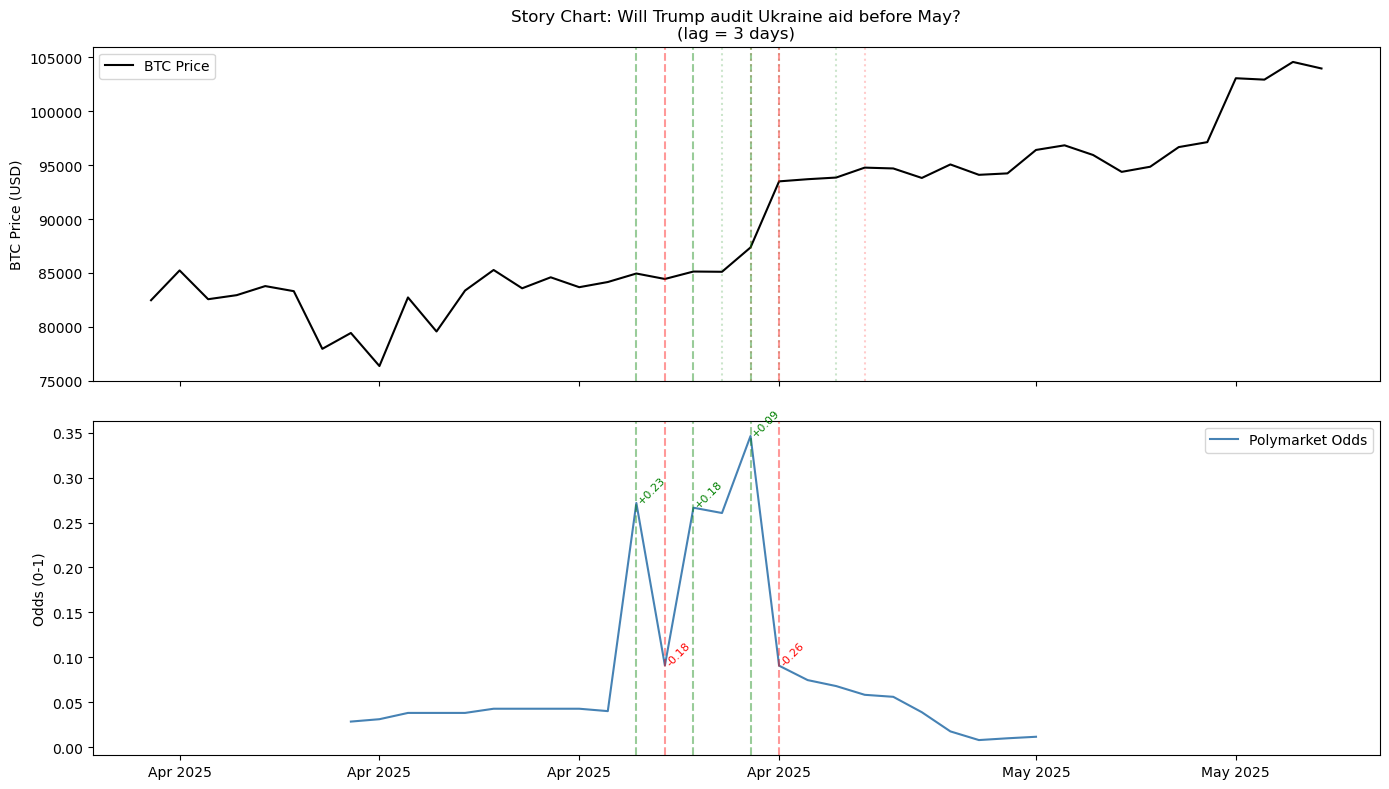

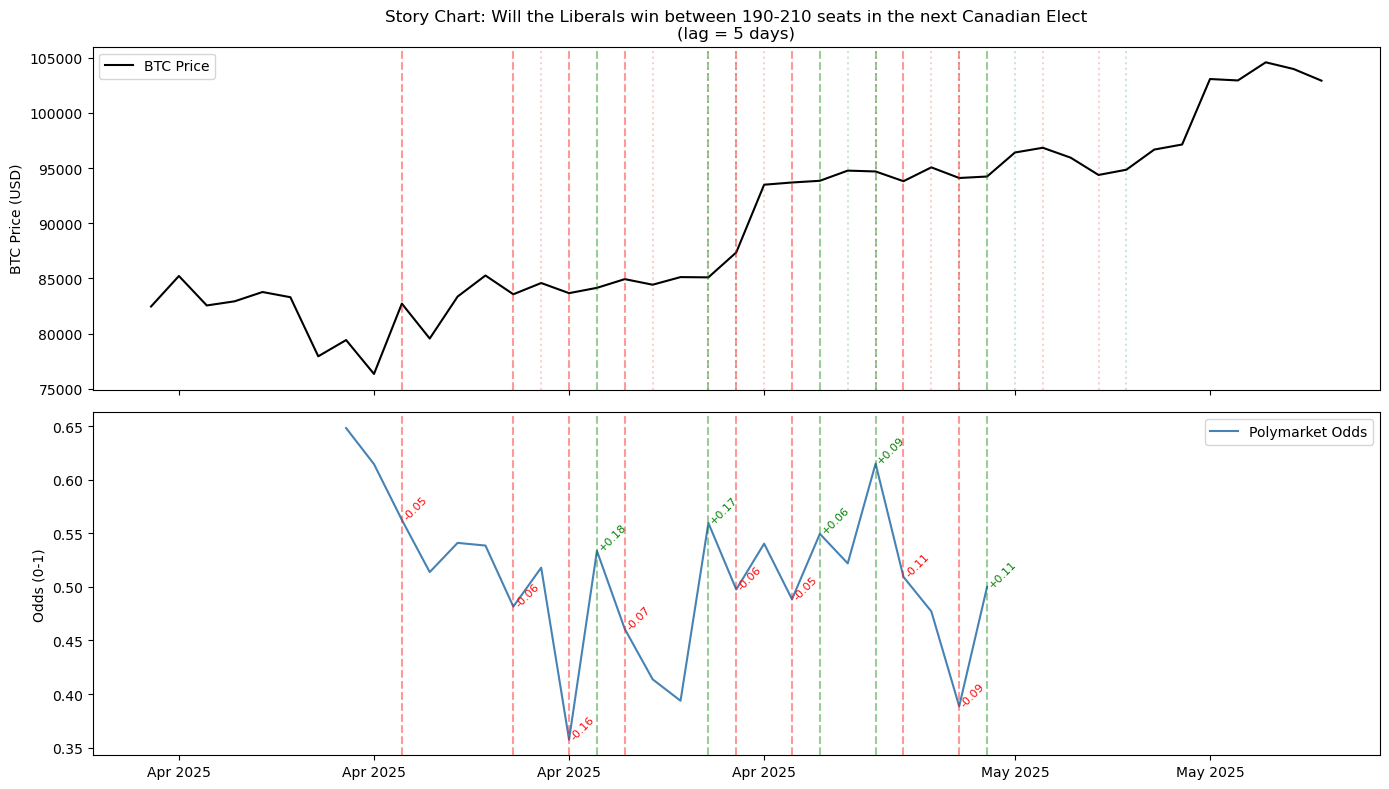

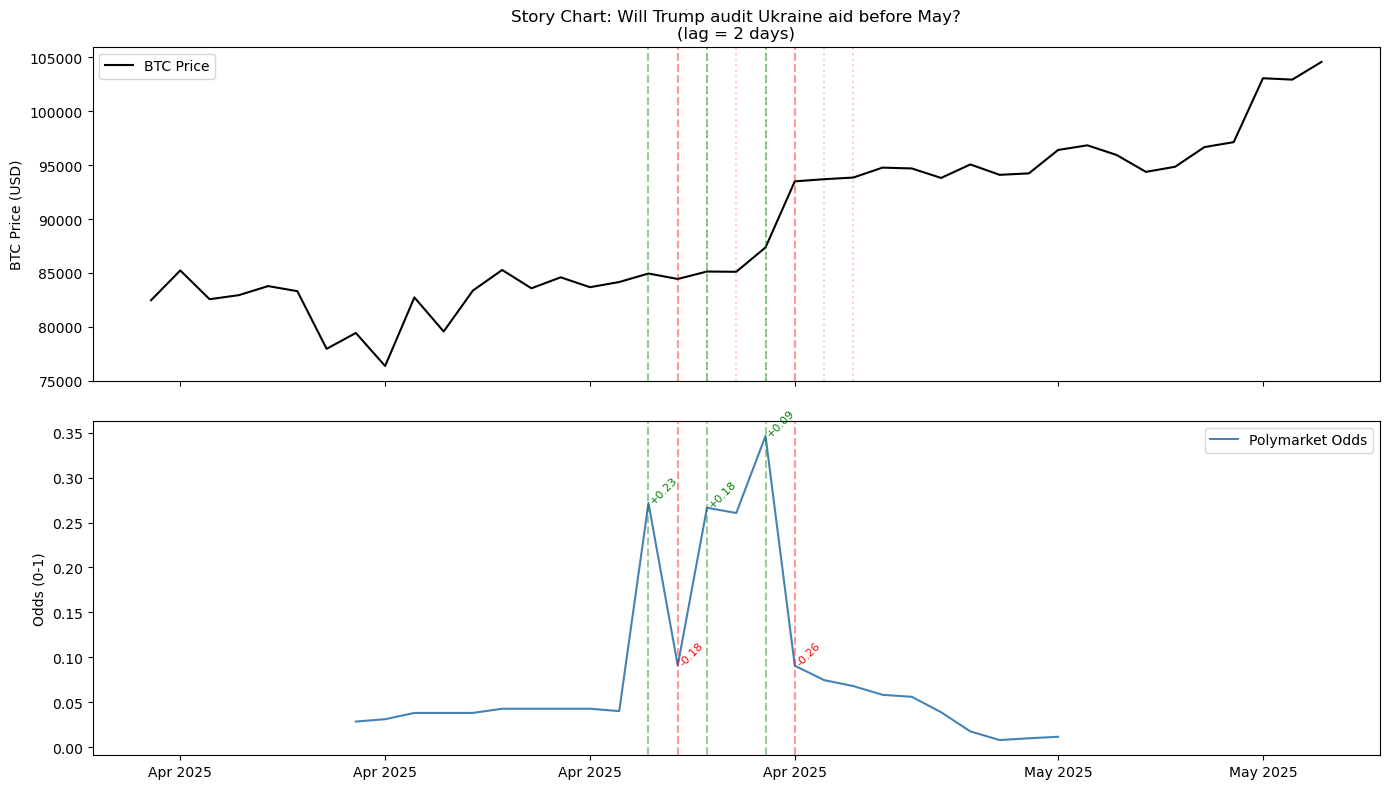

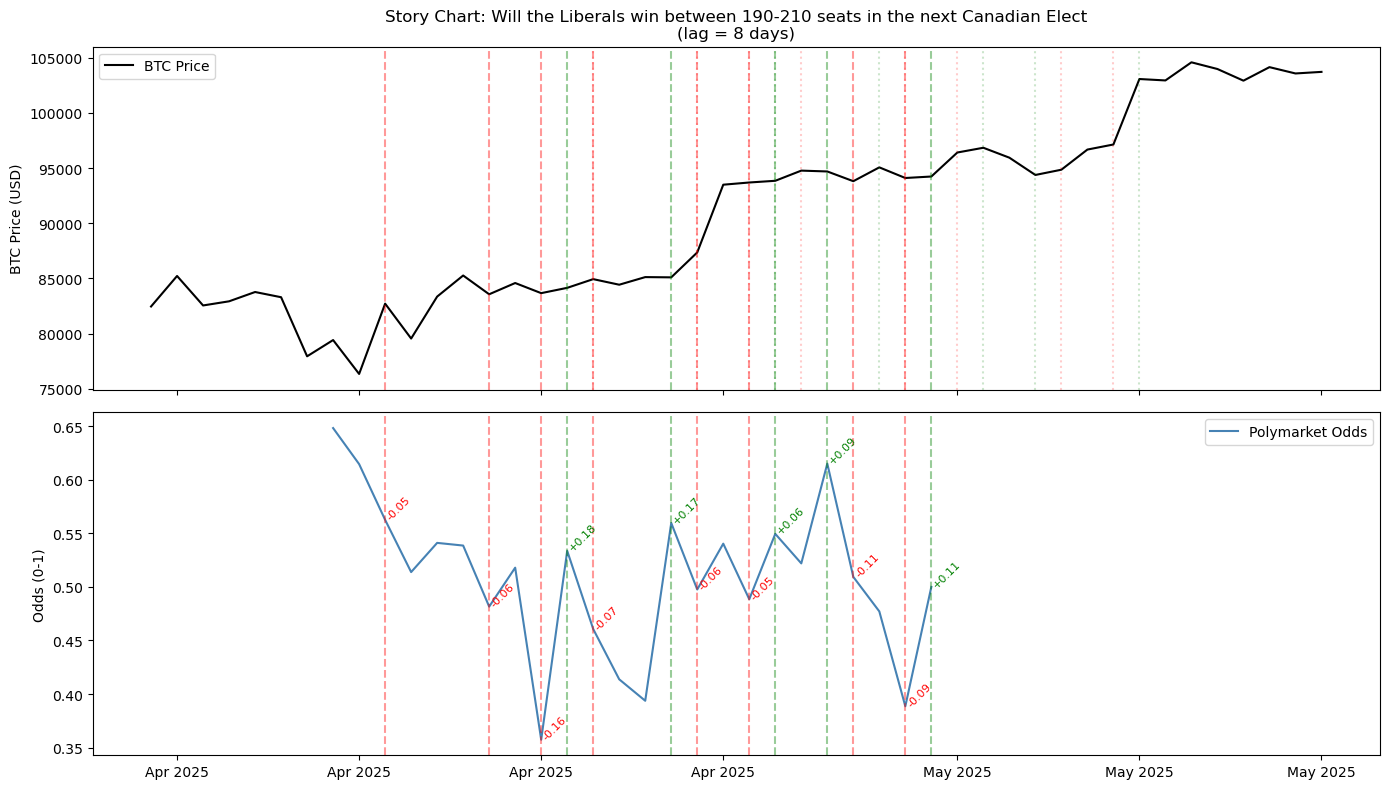

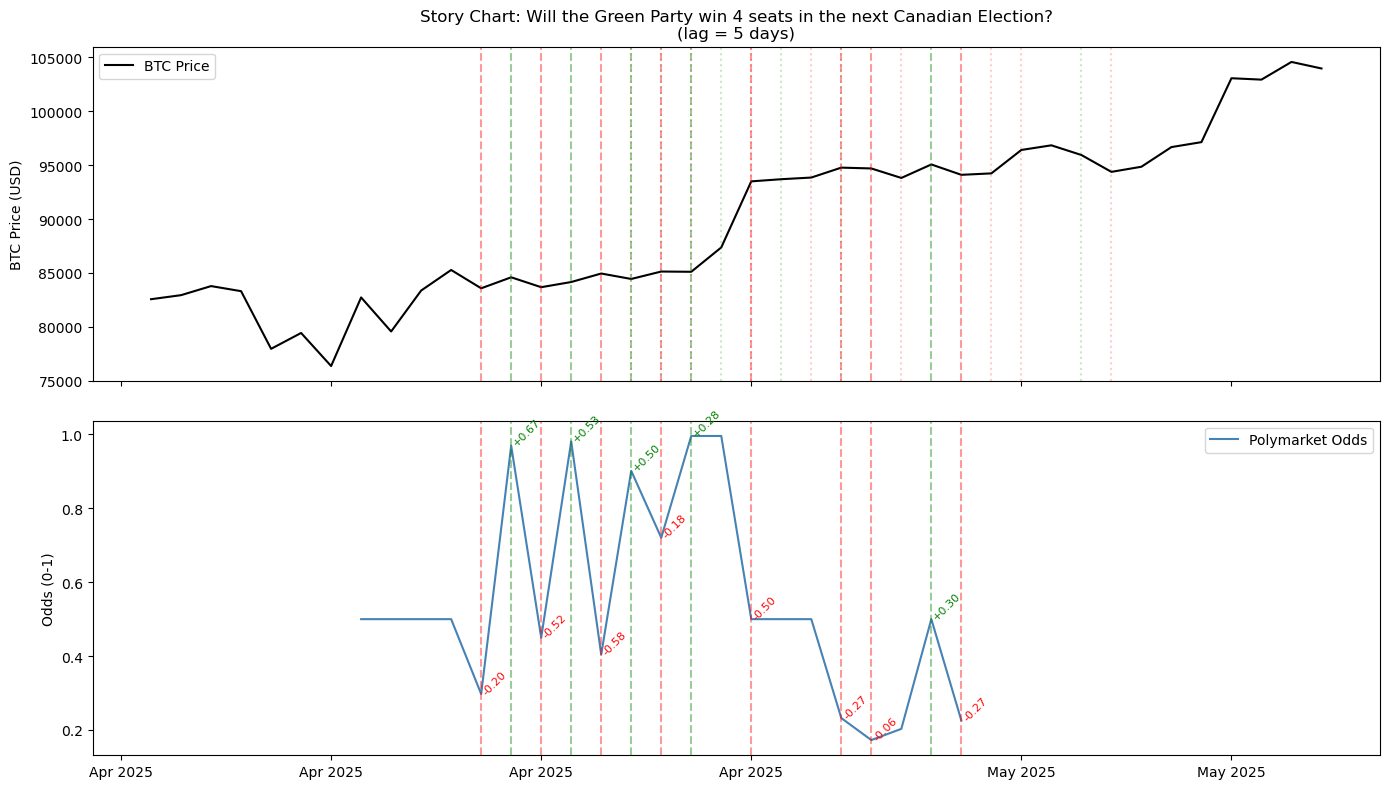

In [201]:
for row in story_candidates.head(5).itertuples():
    plot_story_chart(row.question, row.n_events, daily_odds, btc_df)

In [203]:
os.makedirs("output", exist_ok=True)
story_candidates.to_csv("output/story_candidates.csv", index=False)

In [204]:
# Show top 20 positive and bottom 20 negative
print("=== TOP POSITIVE ===")
print(story_candidates[story_candidates["direction"] == "POSITIVE"]
      .sort_values("avg_btc_return", ascending=False)
      .head(20)
      .to_string(index=False))

print("\n=== TOP NEGATIVE ===")
print(story_candidates[story_candidates["direction"] == "NEGATIVE"]
      .sort_values("avg_btc_return", ascending=True)
      .head(20)
      .to_string(index=False))

=== TOP POSITIVE ===
                                                                                   question direction  avg_btc_return  n_events
                                                   Will Trump audit Ukraine aid before May?  POSITIVE        0.096767         3
                 Will the Liberals win between 190-210 seats in the next Canadian Election?  POSITIVE        0.070920         5
                            Will the Green Party win 4 seats in the next Canadian Election?  POSITIVE        0.055380         5
                                           Gavin Newsom out as California Governor in 2025?  POSITIVE        0.038150         4
                         Will PLC win the most seats in the 2026 Colombian Senate election?  POSITIVE        0.033150         4
                 Will Munyagwa Mubarak Sserunga win the 2026 Ugandan presidential election?  POSITIVE        0.031067         3
                                                   Will Ethereum dip to $4200 in Se

### Step 3 : Interesting point

- most of questions have two ways of odd direction except  4 questions

1. Will Trump agree to a tariff agreement with Brazil in September? (+2.52%)
2. MicroStrategy sells any Bitcoin by December 31, 2026? (+2.31%)
3. Will Raul Perestrello win the 1st round of the 2026 Portugal presidential election? (-0.01%)
4. Will Ethereum close above $3400 on July 31? (-0.22%)


In [206]:
FINAL_CANDIDATES = [
    "Will Trump agree to a tariff agreement with Brazil in September?",
    "MicroStrategy sells any Bitcoin by December 31, 2026?"
]

for q in FINAL_CANDIDATES:
    events = find_events(q, daily_odds)
    print(f"\n{q}")
    print(events[["date", "odds_change", "direction"]])


Will Trump agree to a tariff agreement with Brazil in September?
        date  odds_change direction
0 2025-08-29        -0.09  NEGATIVE
1 2025-08-30        -0.06  NEGATIVE

MicroStrategy sells any Bitcoin by December 31, 2026?
        date  odds_change direction
0 2025-12-16    -0.200000  NEGATIVE
1 2025-12-31     0.060000  POSITIVE
2 2026-01-01    -0.103667  NEGATIVE
3 2026-01-03    -0.327405  NEGATIVE


1. Will Trump agree to a tariff agreement with Brazil in September?

On August 29, 2025, the US Court of Appeals declared the IEEPA tariffs illegal, ruling that the president lacked the authority to impose them under his emergency powers. The tariffs will remain in effect while the administration prepares its appeal to the Supreme Court. The Supreme Court will hear oral arguments on November 5, 2025. 

Previously, On July 9, 2025, Trump’s administration sent letters to 7 more countries and threatened Brazil with a 50 percent tariff that would take effect August 1, 2025.

On July 30, 2025, President Trump signed an executive order imposing an additional 40 percent tariff on Brazil, delaying implementation of the tariff until August 6, 2025, and published a list of exemptions. He also signed an executive order that would end the de minimis exemption for all countries starting August 29, 2025.

NEGATIVE -> odd decrease -> people don't think this will happen

Trade war resolved -> global risk sentiment improved -> Bitcoin up

2. MicroStrategy sells any Bitcoin by December 31, 2026?

MicroStrategy never sell they always buy + NEGATIVE -> confidence in Bitcoin -> Bitcoin up


## Further Study


In [277]:
print(f"Total markets: {len(signal_df)}")
print(signal_df[["question", "signal_days"]].to_string(index=False))

Total markets: 61
                                                                                         question  signal_days
                                                         2026 Balance of Power: R Senate, R House           11
                                Will Nikki Haley win the 2028 Republican presidential nomination?           10
                                                            French election called by October 31?            9
                       Will the Liberals win between 190-210 seats in the next Canadian Election?            8
                                      Will Howard Lutnick leave the Trump administration in 2025?            8
                         Will Luis Gilberto Murillo win the 2026 Colombian presidential election?            8
                                                              Will Solana reach $240 before 2026?            8
                                                                  Will Solana dip to $140 in M

In [278]:
strong = story_candidates[
    (story_candidates["n_events"] >= 3) &
    (story_candidates["avg_btc_return"].abs() > 0.02)
].sort_values("avg_btc_return", ascending=False)

print(f"Strong candidates: {len(strong)}")
print(strong.to_string(index=False))

Strong candidates: 28
                                                                                  question direction  avg_btc_return  n_events
                                                  Will Trump audit Ukraine aid before May?  POSITIVE        0.096767         3
                Will the Liberals win between 190-210 seats in the next Canadian Election?  POSITIVE        0.070920         5
                Will the Liberals win between 190-210 seats in the next Canadian Election?  NEGATIVE        0.057150         8
                           Will the Green Party win 4 seats in the next Canadian Election?  POSITIVE        0.055380         5
                       Will Enrique Peñalosa win the 2026 Colombian presidential election?  NEGATIVE        0.039567         3
                                          Gavin Newsom out as California Governor in 2025?  POSITIVE        0.038150         4
Will Henrique Gouveia e Melo win the 1st round of the 2026 Portugal presidential election

In [298]:
combined = results_df.groupby("question").agg(
    avg_btc_return=("btc_return", "mean"),
    n_events=("event_date", "count"),
).reset_index()

combined = combined[
    (combined["n_events"] >= 3) & 
    ((combined["avg_btc_return"] >= 0.02) | (combined["avg_btc_return"] <= -0.02))
].sort_values("avg_btc_return", ascending=False)

print(combined[["question", "avg_btc_return", "n_events"]].to_string(index=False))

                                                                  question  avg_btc_return  n_events
                                  Will Trump audit Ukraine aid before May?        0.083720         5
Will the Liberals win between 190-210 seats in the next Canadian Election?        0.062446        13
           Will the Green Party win 4 seats in the next Canadian Election?        0.040492        13
                     MicroStrategy sells any Bitcoin by December 31, 2026?        0.035750         4
                                  Will Ethereum dip to $4200 in September?        0.028133         6
                      Will US GDP growth in 2025 be between 2.0% and 2.5%?        0.025943         7
        Will PLC win the most seats in the 2026 Colombian Senate election?        0.025433         6
                         Will Bitcoin reach $190,000 by December 31, 2026?        0.021717         6
       Will Enrique Peñalosa win the 2026 Colombian presidential election?        0.020900 

1. Will Trump audit Ukraine aid before May? 

Ukraine became a global leader in crypto aid, with blockchain analytics firms reporting over $200 million in donations in 2022 alone -> crypto transactions under scrutiny ->
⁇ no conclusion

2. Will the Liberals win between 190-210 seats in the next Canadian Election?

Conservative promote bitcoin as alternative asset -> Liberal win -> bearish bitcoin 
❌ Wrong way

3. Will the Green Party win 4 seats in the next Canadian Election?

⁇ no correlation

4. MicroStrategy sells any Bitcoin by December 31, 2026?

MicroStrategy never sell -> buy more -> odd move up -> bullish bitcoin 
✅ Correct way

5. Will Ethereum dip to $4200 in September?

Crypto market similar -> bearish bitcoin
❌ Wrong way

6. Will US GDP growth in 2025 be between 2.0% and 2.5%?

2.0-2.5% is moderate growth -> good for bitcoin
✅ Correct way

7. Will PLC win most seats in Colombian Senate? 

no direct with bitcoin
⁇ no conclusion

8. Will Bitcoin reach $190,000 by December 31, 2026?

no useful signal
⁇ no conclusion

9. Will Enrique Peñalosa win Colombian election?

no direct with bitcoin
⁇ no conclusion

10. Gavin Newsom out as California Governor in 2025?

California is the center of US tech and crypto industry -> out -> instable -> bearish bitcoin
❌ Wrong way

11. Will Soraya Martinez Ferrada win the 2025 Montreal mayor election?

no direct with bitcoin
⁇ no conclusion

12. French election called by October 31?

instability in Europe -> risky on crypto -> bearish bitcoin
✅ Correct way

13. Will Trump meet with Volodymyr Zelenskyy in September?

Breakthrough Russia-Ukraine -> bullish bitcoin 
no result -> bearish bitcoin
⁇ no conclusion


POLYMARKET FACTORS THAT AFFECT BITCOIN:

1. MicroStrategy selling odds (INSTITUTIONAL SIGNAL)<br>
   When selling odds DROP → Bitcoin UP +3.6%<br>
   Story: World's largest Bitcoin holder confirms <br>
   no selling → supply locked → price supported

2. US GDP growth 2.0-2.5% (MACRO SIGNAL)<br>
   Moderate growth odds → Bitcoin UP +2.6%<br>
   Story: Goldilocks economy → risk appetite <br>
   high → institutional money flows into Bitcoin

3. French election called (POLITICAL RISK SIGNAL)<br>
   When election less likely → Bitcoin DOWN -2.8%<br>
   Story: European political instability → <br>
   risk-off → investors exit crypto

Now, we have 4 questions

1. Will Trump agree to a tariff agreement with Brazil in September?<br>
    On August 29, 2025, the US Court of Appeals declared the IEEPA tariffs illegal, ruling that the president lacked the authority to impose them under his emergency powers. The tariffs will remain in effect while the administration prepares its appeal to the Supreme Court. The Supreme Court will hear oral arguments on November 5, 2025. <br>
    Previously, On July 9, 2025, Trump’s administration sent letters to 7 more countries and threatened Brazil with a 50 percent tariff that would take effect August 1, 2025.<br>
    On July 30, 2025, President Trump signed an executive order imposing an additional 40 percent tariff on Brazil, delaying implementation of the tariff until August 6, 2025, and published a list of exemptions. He also signed an executive order that would end the de minimis exemption for all countries starting August 29, 2025.<br>
    NEGATIVE -> odd decrease -> people don't think this will happen<br>
    Trade war resolved -> global risk sentiment improved -> Bitcoin up

2. MicroStrategy sells any Bitcoin by December 31, 2026?<br>
    MicroStrategy never sell they always buy + NEGATIVE -> confidence in Bitcoin -> Bitcoin up<br>

3. US GDP growth 2.0-2.5% (MACRO SIGNAL)<br>
   Moderate growth odds → Bitcoin UP +2.6%<br>
   Story: Goldilocks economy → risk appetite <br>
   high → institutional money flows into Bitcoin

4. French election called (POLITICAL RISK SIGNAL)<br>
   When election less likely → Bitcoin DOWN -2.8%<br>
   Story: European political instability → <br>
   risk-off → investors exit crypto


In [300]:
# Find ALL tariff related questions in your data
tariff_keywords = [
    "tariff", "trade deal", "trade war", 
    "trade agreement", "import tax", "liberation day",
    "reciprocal tariff", "trade deficit"
]

tariff_markets = poly_data_markets[
    poly_data_markets["question"].apply(
        lambda q: any(kw.lower() in q.lower() for kw in tariff_keywords)
    )
]

print(f"Tariff related markets: {len(tariff_markets)}")
print(tariff_markets[["question", "volume"]].sort_values("volume", ascending=False).to_string())

Tariff related markets: 315
                                                                                                      question        volume
8136                                                              Will Trump lower tariffs on China in April?   1.102075e+07
5263                                         Will Trump impose 25% tariff on Mexico or Canada before February?  2.789313e+06
22732                                                         Supreme Court rules in favor of Trump's tariffs?  1.465692e+06
5127                                                   Will Trump impose large tariffs in his first 6 months?   1.443302e+06
44095                                                             Will Trump create a tariff dividend in 2025?  1.416184e+06
6450                                                         Will Trump increase tariffs on Mexico before May?  1.186486e+06
5175                                                      Trump imposes 40% tariff on China in fi

/var/folders/hn/pyg79cw15ql332wmddc7h_6c0000gn/T/ipykernel_38718/906447611.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tariff_markets["type"] = tariff_markets["question"].apply(classify_tariff_question)


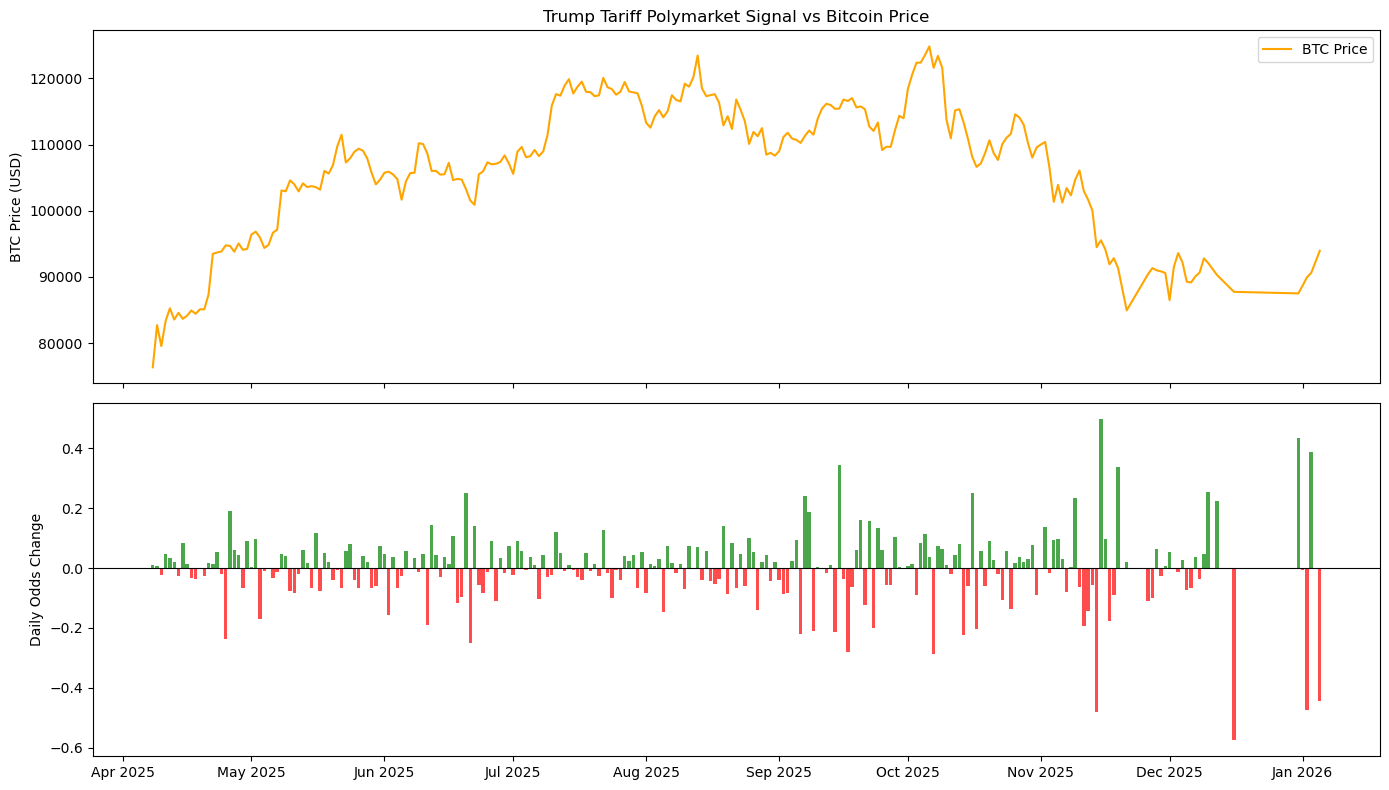


Tariff signal correlation with Bitcoin returns:
  Lag  1 days: -0.038
  Lag  3 days: +0.031
  Lag  5 days: -0.080
  Lag  7 days: -0.005
  Lag 10 days: +0.022
  Lag 14 days: +0.005


In [302]:
# Build daily tariff sentiment signal
tariff_odds = daily_odds[
    daily_odds["market_id"].isin(tariff_markets["market_id"])
].copy()

# Classify each question as ESCALATION or DE-ESCALATION
def classify_tariff_question(question):
    q = question.lower()
    # De-escalation = good for Bitcoin
    if any(kw in q for kw in ["deal", "agreement", "pause", "reduce", "end", "lift"]):
        return "DE-ESCALATION"
    # Escalation = bad for Bitcoin
    elif any(kw in q for kw in ["impose", "increase", "50%", "100%", "new tariff"]):
        return "ESCALATION"
    else:
        return "UNCLEAR"

tariff_markets["type"] = tariff_markets["question"].apply(classify_tariff_question)

# Daily average odds change
tariff_signal = (
    tariff_odds
    .groupby("date")["price"]
    .mean()
    .reset_index()
    .sort_values("date")
    .set_index("date")
)
tariff_signal["odds_change"] = tariff_signal["price"].diff()

# Align with Bitcoin
combined = pd.concat([
    tariff_signal[["price", "odds_change"]],
    btc_df[["PriceUSD"]]
], axis=1).dropna()

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(combined.index, combined["PriceUSD"], color="orange", lw=1.5, label="BTC Price")
ax1.set_ylabel("BTC Price (USD)")
ax1.set_title("Trump Tariff Polymarket Signal vs Bitcoin Price")
ax1.legend()

colors = ["green" if x > 0 else "red" for x in combined["odds_change"]]
ax2.bar(combined.index, combined["odds_change"], color=colors, alpha=0.7)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Daily Odds Change")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.savefig("tariff_signal.png", dpi=150)
plt.show()

# Correlation at different lags
print("\nTariff signal correlation with Bitcoin returns:")
for lag in [1, 3, 5, 7, 10, 14]:
    btc_return = combined["PriceUSD"].pct_change(lag).shift(-lag)
    corr = combined["odds_change"].corr(btc_return)
    print(f"  Lag {lag:2d} days: {corr:+.3f}")


In [304]:
# Split into two signals instead of averaging all together

# De-escalation markets (deal/pause = good for Bitcoin)
deescalation_markets = tariff_markets[
    tariff_markets["type"] == "DE-ESCALATION"
]

# Escalation markets (new tariffs = bad for Bitcoin)
escalation_markets = tariff_markets[
    tariff_markets["type"] == "ESCALATION"
]

# Build separate signals
deescalation_odds = daily_odds[
    daily_odds["market_id"].isin(deescalation_markets["market_id"])
].groupby("date")["price"].mean()

escalation_odds = daily_odds[
    daily_odds["market_id"].isin(escalation_markets["market_id"])
].groupby("date")["price"].mean()

# Print what questions fall into each category
print("DE-ESCALATION markets:")
print(deescalation_markets["question"])

print("\nESCALATION markets:")
print(escalation_markets["question"])

DE-ESCALATION markets:
7262     Will Trump reduce tariffs on Mexico or Canada ...
8144     Will Trump reduce majority of tariffs before J...
8145     Will Trump reduce or pause tariffs on Vietnam ...
8146     Will Trump reduce or pause tariffs on Cambodia...
8147     Will Trump reduce or pause tariffs on Laos bef...
                               ...                        
70305    Will Trump agree to a tariff agreement with Me...
70306    Will Trump agree to a tariff agreement with Ch...
70307    Will Trump agree to a tariff agreement with Au...
70308    Will Trump agree to a tariff agreement with Is...
70309    Will Trump agree to a tariff agreement with Ca...
Name: question, Length: 110, dtype: object

ESCALATION markets:
5127     Will Trump impose large tariffs in his first 6...
5175     Trump imposes 40% tariff on China in first 100...
5263     Will Trump impose 25% tariff on Mexico or Cana...
5872     Will Trump impose tariffs on China in his firs...
5873     Will Trump impose t

=== DE-ESCALATION signal (deal/pause odds) ===
Expected: odds UP → Bitcoin UP (good news)
  Lag  1 days: -0.068
  Lag  3 days: +0.064
  Lag  5 days: +0.050
  Lag  7 days: +0.091
  Lag 10 days: +0.044
  Lag 14 days: +0.014

=== ESCALATION signal (new tariff odds) ===
Expected: odds UP → Bitcoin DOWN (bad news)
  Lag  1 days: -0.029
  Lag  3 days: +0.055
  Lag  5 days: -0.109
  Lag  7 days: +0.001
  Lag 10 days: +0.004
  Lag 14 days: +0.015


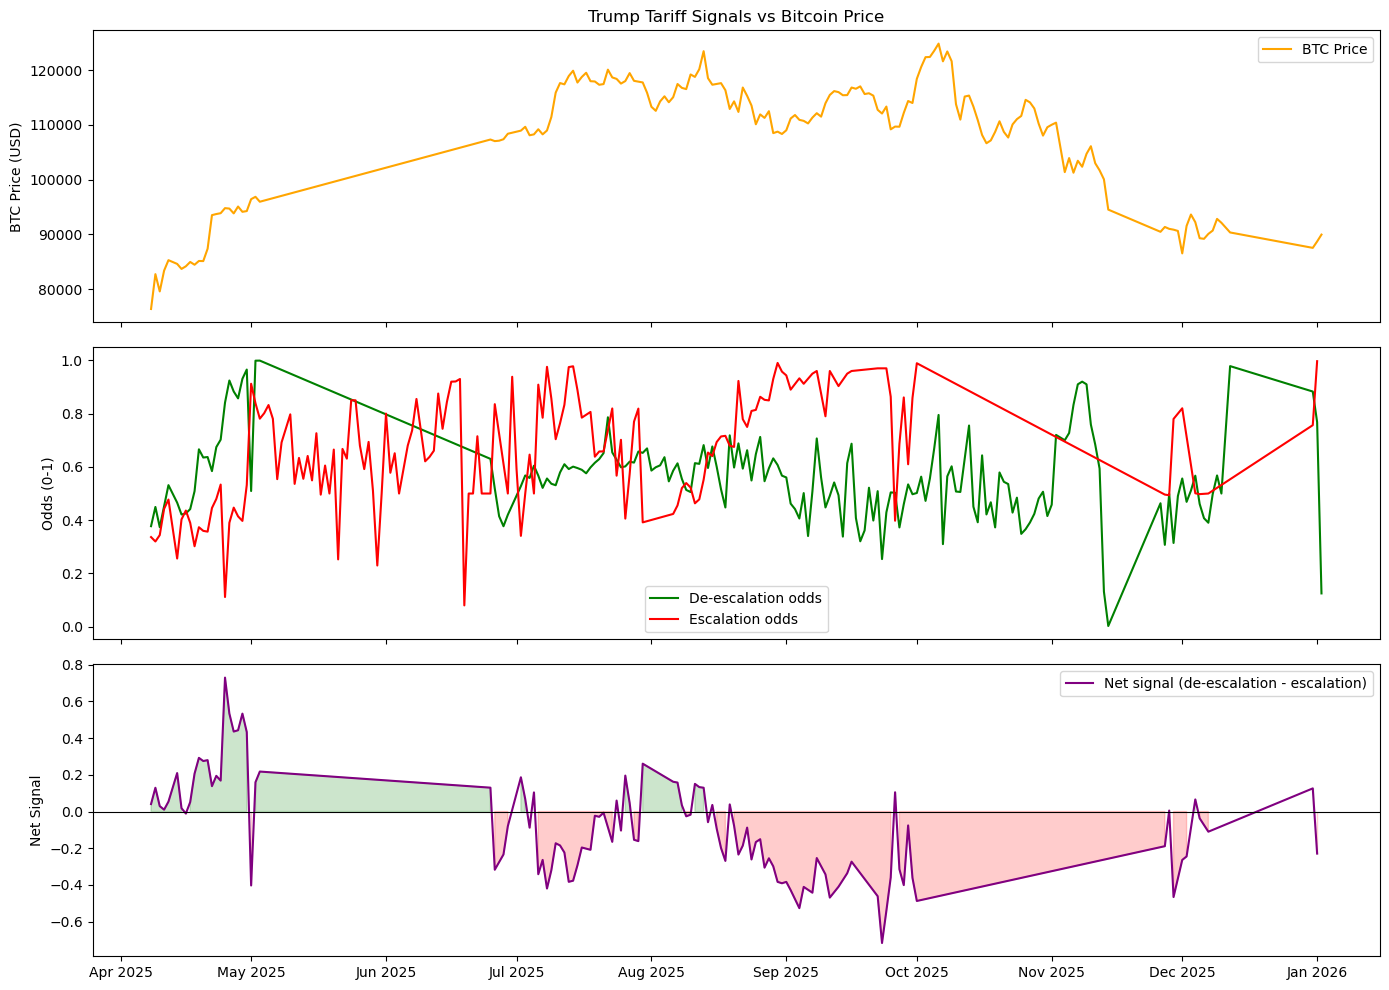


=== NET SIGNAL correlation (de-escalation - escalation) ===
  Lag  1 days: +0.163
  Lag  3 days: +0.197
  Lag  5 days: +0.317
  Lag  7 days: +0.349
  Lag 10 days: +0.517
  Lag 14 days: +0.534


In [306]:
# Build separate daily signals
def build_signal(market_ids, daily_odds_df):
    odds = daily_odds_df[
        daily_odds_df["market_id"].isin(market_ids)
    ].copy()
    
    signal = (
        odds.groupby("date")["price"]
        .mean()
        .reset_index()
        .sort_values("date")
        .set_index("date")
    )
    signal["odds_change"] = signal["price"].diff()
    return signal

deescalation_signal = build_signal(
    deescalation_markets["market_id"], daily_odds
)
escalation_signal = build_signal(
    escalation_markets["market_id"], daily_odds
)

# Align with Bitcoin
def get_combined(signal, btc_df):
    return pd.concat([
        signal[["price", "odds_change"]],
        btc_df[["PriceUSD"]]
    ], axis=1).dropna()

combined_de = get_combined(deescalation_signal, btc_df)
combined_es = get_combined(escalation_signal, btc_df)

# Correlation at different lags for each
print("=== DE-ESCALATION signal (deal/pause odds) ===")
print("Expected: odds UP → Bitcoin UP (good news)")
for lag in [1, 3, 5, 7, 10, 14]:
    btc_return = combined_de["PriceUSD"].pct_change(lag).shift(-lag)
    corr = combined_de["odds_change"].corr(btc_return)
    print(f"  Lag {lag:2d} days: {corr:+.3f}")

print("\n=== ESCALATION signal (new tariff odds) ===")
print("Expected: odds UP → Bitcoin DOWN (bad news)")
for lag in [1, 3, 5, 7, 10, 14]:
    btc_return = combined_es["PriceUSD"].pct_change(lag).shift(-lag)
    corr = combined_es["odds_change"].corr(btc_return)
    print(f"  Lag {lag:2d} days: {corr:+.3f}")

# Also plot both signals vs Bitcoin
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(combined_de.index, combined_de["PriceUSD"], 
             color="orange", lw=1.5, label="BTC Price")
axes[0].set_ylabel("BTC Price (USD)")
axes[0].set_title("Trump Tariff Signals vs Bitcoin Price")
axes[0].legend()

axes[1].plot(combined_de.index, combined_de["price"],
             color="green", lw=1.5, label="De-escalation odds")
axes[1].plot(combined_es.index, combined_es["price"],
             color="red", lw=1.5, label="Escalation odds")
axes[1].set_ylabel("Odds (0-1)")
axes[1].legend()

# Net signal = de-escalation - escalation
combined_net = pd.concat([
    combined_de["price"].rename("deescalation"),
    combined_es["price"].rename("escalation")
], axis=1).dropna()
combined_net["net_signal"] = combined_net["deescalation"] - combined_net["escalation"]

axes[2].plot(combined_net.index, combined_net["net_signal"],
             color="purple", lw=1.5, label="Net signal (de-escalation - escalation)")
axes[2].axhline(0, color="black", lw=0.8)
axes[2].fill_between(combined_net.index, combined_net["net_signal"], 0,
                     where=combined_net["net_signal"] > 0, color="green", alpha=0.2)
axes[2].fill_between(combined_net.index, combined_net["net_signal"], 0,
                     where=combined_net["net_signal"] < 0, color="red", alpha=0.2)
axes[2].set_ylabel("Net Signal")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[2].legend()

plt.tight_layout()
plt.savefig("tariff_signal_split.png", dpi=150)
plt.show()

# Net signal correlation
print("\n=== NET SIGNAL correlation (de-escalation - escalation) ===")
combined_all = pd.concat([
    combined_net["net_signal"],
    btc_df["PriceUSD"]
], axis=1).dropna()

for lag in [1, 3, 5, 7, 10, 14]:
    btc_return = combined_all["PriceUSD"].pct_change(lag).shift(-lag)
    corr = combined_all["net_signal"].corr(btc_return)
    print(f"  Lag {lag:2d} days: {corr:+.3f}")



The key addition here is the **net signal** at the bottom — `de-escalation odds minus escalation odds`. This gives you one clean number that says:

Net signal > 0 → market believes trade war resolving → Bitcoin should go UP<br>
Net signal < 0 → market believes trade war escalating → Bitcoin should go DOWN<br>

## Summary

Step 1 : ACF Analysis<br>
I ran autocorrelation on daily odds changes for each Polymarket question to find how long each market's signal persists.<br>
Get rid of less than 3 days. -> mostly 5-11 days

Step 2 : Event Study<br>
found date that odd change more than 5 percent in one day -> direction and average bitcoin return <br>
-> direction odds and avg_btc_return same way -> 2 question<br>

1. Will Trump agree to a tariff agreement with Brazil in September?<br>

2. MicroStrategy sells any Bitcoin by December 31, 2026?<br>

-> do not care direction -> question with high average bitcoin return and reasonable cause -> 3 questions

1. MicroStrategy sells any Bitcoin by December 31, 2026?<br>

2. US GDP growth 2.0-2.5% (MACRO SIGNAL)<br>

3. French election called (POLITICAL RISK SIGNAL)<br>

Step 3 : Theme of question

We first work on Tariff<br>
Search on list of question with<br>
- De-escalation (110 markets) — deal, pause, reduce, agreement
- Escalation — impose, increase, new tariff

=== NET SIGNAL correlation with btc_change daily (de-escalation - escalation) ===
  Lag  1 days: +0.163
  Lag  3 days: +0.197
  Lag  5 days: +0.317
  Lag  7 days: +0.349
  Lag 10 days: +0.517
  Lag 14 days: +0.534


Story behind:

Trump announces/escalates tariffs
→ Escalation odds rise on Polymarket
→ Net signal goes negative
→ Risk-off sentiment builds
→ Bitcoin falls 10-14 days later

Trump pauses/reduces tariffs
→ De-escalation odds rise on Polymarket
→ Net signal goes positive  
→ Risk-on sentiment returns
→ Bitcoin rises 10-14 days later